# The more "special properties" there are in a county, the lower the average price of real estate will be (Niko)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('/content/sample_data/GA_RE_cleaned_updated.csv')
df

<ipython-input-2-48ea7cffa333>:1: DtypeWarning: Columns (24,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/sample_data/GA_RE_cleaned_updated.csv')


,Unnamed: 0,status,price,bed,bath,acre_lot,city,zip_code,house_size,prev_sold_date,...,2014 Unemployment Rate,2015 Unemployment Rate,2016 Unemployment Rate,2017 Unemployment Rate,2018 Unemployment Rate,2019 Unemployment Rate,2020 Unemployment Rate,2021 Unemployment Rate,2022 Unemployment Rate,2023 Unemployment Rate
0,0,for_sale,531625.0,5.0,4.0,NaN,Hampton,30228,3661.0,NaN,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
1,1,for_sale,525210.0,5.0,4.0,NaN,Hampton,30228,3661.0,10/31/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
2,2,for_sale,490225.0,5.0,3.0,NaN,Hampton,30228,3116.0,10/27/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
3,3,for_sale,481705.0,5.0,3.0,NaN,Hampton,30228,3116.0,7/20/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
4,4,for_sale,145000.0,NaN,NaN,0.91,Lincolnton,30817,NaN,NaN,...,8.30%,6.90%,6.00%,5.30%,5.00%,4.00%,5.40%,4.10%,3.60%,3.80%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36420,36420,for_sale,149900.0,4.0,1.0,0.64,Whigham,39897,1994.0,NaN,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36421,36421,for_sale,137889.0,3.0,2.0,2.30,Whigham,39897,1458.0,12/3/1999,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36422,36422,for_sale,25000.0,NaN,NaN,3.00,Albany,31721,NaN,3/26/2010,...,9.30%,7.90%,6.90%,6.10%,5.40%,4.80%,8.60%,6.30%,4.50%,4.30%
36423,36423,for_sale,635000.0,NaN,NaN,1.35,Suwanee,30024,NaN,5/11/2022,...,6.10%,5.30%,4.80%,4.30%,3.60%,3.20%,6.30%,3.50%,2.80%,2.90%


In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df

,status,price,bed,bath,acre_lot,city,zip_code,house_size,prev_sold_date,Special_property,...,2014 Unemployment Rate,2015 Unemployment Rate,2016 Unemployment Rate,2017 Unemployment Rate,2018 Unemployment Rate,2019 Unemployment Rate,2020 Unemployment Rate,2021 Unemployment Rate,2022 Unemployment Rate,2023 Unemployment Rate
0,for_sale,531625.0,5.0,4.0,NaN,Hampton,30228,3661.0,NaN,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
1,for_sale,525210.0,5.0,4.0,NaN,Hampton,30228,3661.0,10/31/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
2,for_sale,490225.0,5.0,3.0,NaN,Hampton,30228,3116.0,10/27/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
3,for_sale,481705.0,5.0,3.0,NaN,Hampton,30228,3116.0,7/20/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
4,for_sale,145000.0,NaN,NaN,0.91,Lincolnton,30817,NaN,NaN,True,...,8.30%,6.90%,6.00%,5.30%,5.00%,4.00%,5.40%,4.10%,3.60%,3.80%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36420,for_sale,149900.0,4.0,1.0,0.64,Whigham,39897,1994.0,NaN,False,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36421,for_sale,137889.0,3.0,2.0,2.30,Whigham,39897,1458.0,12/3/1999,False,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36422,for_sale,25000.0,NaN,NaN,3.00,Albany,31721,NaN,3/26/2010,True,...,9.30%,7.90%,6.90%,6.10%,5.40%,4.80%,8.60%,6.30%,4.50%,4.30%
36423,for_sale,635000.0,NaN,NaN,1.35,Suwanee,30024,NaN,5/11/2022,True,...,6.10%,5.30%,4.80%,4.30%,3.60%,3.20%,6.30%,3.50%,2.80%,2.90%


In [ ]:
plot_df = df.groupby('County').agg(SP_count = ('Special_property', 'sum'), avg_value = ('price', 'mean'))
plot_df

,SP_count,avg_value
County,,
Appling,20,250019.534884
Atkinson,1,195133.000000
Bacon,10,356860.227273
Baker,1,45000.000000
Baldwin,108,223359.266667
...,...,...
Whitfield,113,301460.594249
Wilcox,4,252092.857143
Wilkes,12,350961.875000


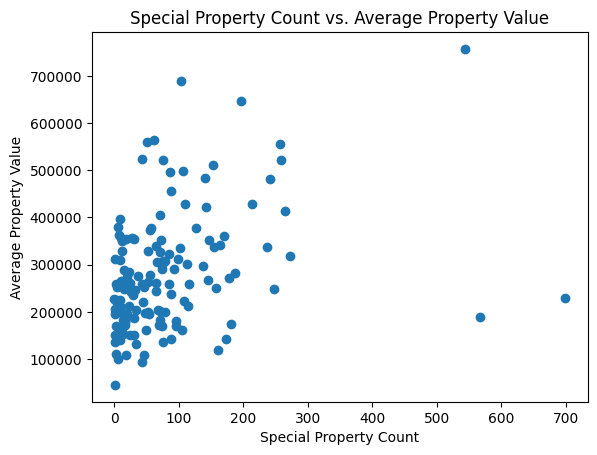

In [ ]:
# Plot comparing the number of "special properties" to the average cost of real estate per county to see if there
# is any correlation.
plt.scatter(plot_df['SP_count'], plot_df['avg_value'])
plt.xlabel('Special Property Count')
plt.ylabel('Average Property Value')
plt.title('Special Property Count vs. Average Property Value')
plt.show()

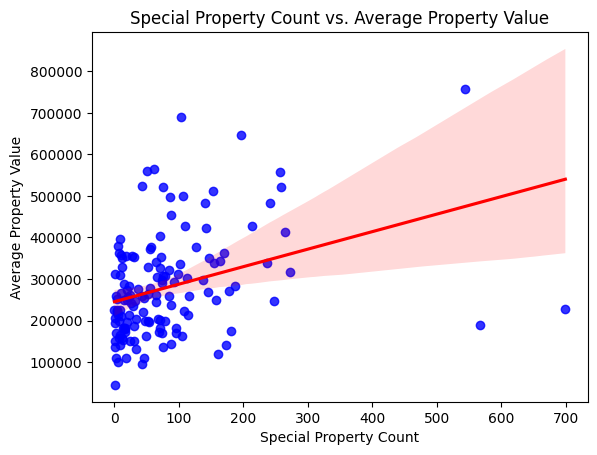

In [ ]:
# Using linear regression to see more clearly what is going in here. Due to how shallow the incline is, and the fact that
# most data points fall outside the confidence interval, it is safe to say there is little to no correlation
# between the number of "special properties" and the average cost of real estate.
sns.regplot(x=plot_df['SP_count'], y=plot_df['avg_value'], scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.xlabel('Special Property Count')
plt.ylabel('Average Property Value')
plt.title('Special Property Count vs. Average Property Value')
plt.show()

In [ ]:
# Finding the correlation coefficient to further support my claim
correlation_matrix_1 = np.corrcoef(plot_df['SP_count'], plot_df['avg_value'])
correlation_1 = correlation_matrix_1[0, 1]
print(correlation_1)

0.3437061308718002


In [ ]:
plot_df['SP_ratio'] = df.groupby('County')['Special_property'].sum() / df.groupby('County')['County'].count()
plot_df

,SP_count,avg_value,SP_ratio
County,,,
Appling,20,250019.534884,0.465116
Atkinson,1,195133.000000,0.333333
Bacon,10,356860.227273,0.454545
Baker,1,45000.000000,1.000000
Baldwin,108,223359.266667,0.450000
...,...,...,...
Whitfield,113,301460.594249,0.361022
Wilcox,4,252092.857143,0.285714
Wilkes,12,350961.875000,0.375000


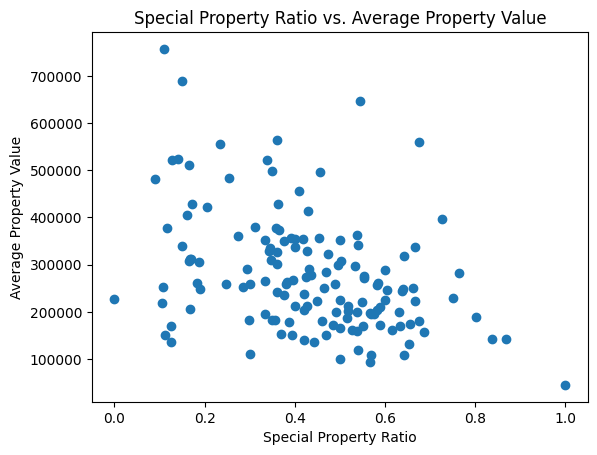

In [ ]:
# Plot to see if there is a correlation between the ratio of special properties
plt.scatter(plot_df['SP_ratio'], plot_df['avg_value'])
plt.xlabel('Special Property Ratio')
plt.ylabel('Average Property Value')
plt.title('Special Property Ratio vs. Average Property Value')
plt.show()

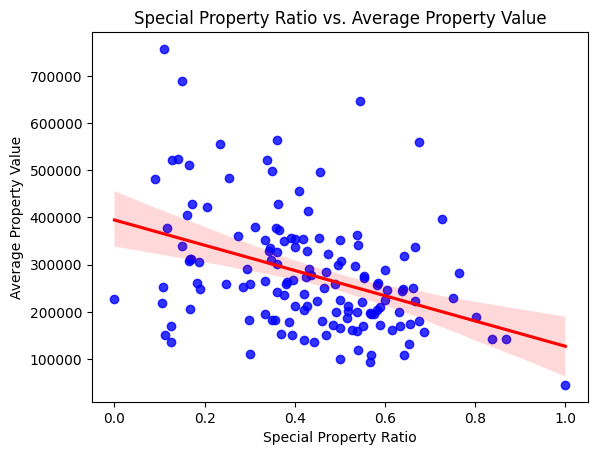

In [ ]:
sns.regplot(x=plot_df['SP_ratio'], y=plot_df['avg_value'], scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.xlabel('Special Property Ratio')
plt.ylabel('Average Property Value')
plt.title('Special Property Ratio vs. Average Property Value')
plt.show()

In [ ]:
correlaton_matrix = np.corrcoef(plot_df['SP_ratio'], plot_df['avg_value'])
correlaton = correlaton_matrix[0, 1]
print(correlaton)

-0.39488916648686095


As we can see above, there is generally not a very strong correlation between average price and either the number of special properties or the ratio of special properties. Both methods produce correlation coefficients of 0.3437 and -0.3949 respectively, which both indicate that while there may be a correlation, it is relatively weak.

# Property located near major cities will have a higher average price (Niko)

In [ ]:
import folium as fl
import branca as bc
import geopandas as gpd
import pandas as pd
from geopy.geocoders import Nominatim
import time

## Finding the ten largest cities in Georgia

In [ ]:
# Pulling data from wiki page on Georgia municipalities
GA_tables = pd.read_html("https://en.wikipedia.org/wiki/List_of_municipalities_in_Georgia_%28U.S._state%29")
GA_tables

[               Name Type[1]         County[1] Population (2020)[3]  \
                Name Type[1]         County[1] Population (2020)[3]   
 0       Abbeville †    City            Wilcox                 2685   
 1           Acworth    City              Cobb                22440   
 2       Adairsville    City            Bartow                 4878   
 3            Adel †    City              Cook                 5571   
 4            Adrian    City  Emanuel, Johnson                  552   
 ..              ...     ...               ...                  ...   
 534           Wrens    City         Jefferson                 2217   
 535  Wrightsville †    City           Johnson                 3449   
 536      Yatesville    Town             Upson                  394   
 537    Young Harris    City             Towns                 1098   
 538       Zebulon †    City              Pike                 1225   
 
     Population (2010)[3] Change (%) Land area (2010)[1]        \
     Popu

In [ ]:
# Selecting the specific table that relates to cities
GA_Cities = GA_tables[0]
GA_Cities

Name Type[1]         County[1] Population (2020)[3]  \
               Name Type[1]         County[1] Population (2020)[3]   
0       Abbeville †    City            Wilcox                 2685   
1           Acworth    City              Cobb                22440   
2       Adairsville    City            Bartow                 4878   
3            Adel †    City              Cook                 5571   
4            Adrian    City  Emanuel, Johnson                  552   
..              ...     ...               ...                  ...   
534           Wrens    City         Jefferson                 2217   
535  Wrightsville †    City           Johnson                 3449   
536      Yatesville    Town             Upson                  394   
537    Young Harris    City             Towns                 1098   
538       Zebulon †    City              Pike                 1225   

    Population (2010)[3] Change (%) Land area (2010)[1]        \
    Population (2010)[3] Change (%)               sq mi   km2   
0                   2908      −7.7%                3.06   7.9   
1                  20425      +9.9%                8.24  21.3   
2                   4648      +4.9%                9.11  23.6   
3                   5334      +4.4%                8.06  20.9   
4                    664     −16.9%                1.37   3.5   
..                   ...        ...                 ...   ...   
534                 2187      +1.4%                3.13   8.1   
535                 2195     +57.1%                3.52   9.1   
536                  357     +10.4%                0.86   2.2   
537                  899     +22.1%                1.06   2.7   
538                 1174      +4.3%                4.46  11.6   

              Population density  
              Population density  
0        877.5/sq mi (338.8/km2)  
1    2,723.3/sq mi (1,051.5/km2)  
2        535.5/sq mi (206.7/km2)  
3        691.2/sq mi (266.9/km2)  
4        402.9/sq mi (155.6/km2)  
..                           ...  
534      708.3/sq mi (273.5/km2)  
535      979.8/sq mi (378.3/km2)  
536      458.1/sq mi (176.9/km2)  
537    1,035.8/sq mi (399.9/km2)  
538      274.7/sq mi (106.0/km2)  

[539 rows x 9 columns]

In [ ]:
# Selecting relevant columns and adding a sequential column to use as index
GA_Cities = GA_Cities[['Name', 'Type[1]', 'County[1]', 'Population (2020)[3]']]
GA_Cities.insert(0, 'ID', range(1, 1 + len(GA_Cities)))
GA_Cities

,ID,Name,Type[1],County[1],Population (2020)[3]
,,Name,Type[1],County[1],Population (2020)[3]
0,1,Abbeville †,City,Wilcox,2685
1,2,Acworth,City,Cobb,22440
2,3,Adairsville,City,Bartow,4878
3,4,Adel †,City,Cook,5571
4,5,Adrian,City,"Emanuel, Johnson",552
...,...,...,...,...,...
534,535,Wrens,City,Jefferson,2217
535,536,Wrightsville †,City,Johnson,3449
536,537,Yatesville,Town,Upson,394


In [ ]:
# Setting ID column as index
GA_Cities.set_index('ID', inplace = True)
GA_Cities

,Name,Type[1],County[1],Population (2020)[3]
,Name,Type[1],County[1],Population (2020)[3]
ID,,,,
1,Abbeville †,City,Wilcox,2685
2,Acworth,City,Cobb,22440
3,Adairsville,City,Bartow,4878
4,Adel †,City,Cook,5571
5,Adrian,City,"Emanuel, Johnson",552
...,...,...,...,...
535,Wrens,City,Jefferson,2217
536,Wrightsville †,City,Johnson,3449


In [ ]:
# going down to the base level of hierarchy, filtering the dataframe to only include cities, and renaming columns
GA_Cities.columns = GA_Cities.columns.get_level_values(0)
GA_Cities = GA_Cities.loc[GA_Cities['Type[1]'] == 'City']
GA_Cities.rename(columns = {'Name':'City', 'County[1]':'County', 'Population (2020)[3]':'Population'}, inplace = True)
GA_Cities.drop(columns = ['Type[1]'], inplace = True)
GA_Cities

<ipython-input-7-7cbd03e002af>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GA_Cities.rename(columns = {'Name':'City', 'County[1]':'County', 'Population (2020)[3]':'Population'}, inplace = True)
<ipython-input-7-7cbd03e002af>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GA_Cities.drop(columns = ['Type[1]'], inplace = True)


,City,County,Population
ID,,,
1,Abbeville †,Wilcox,2685
2,Acworth,Cobb,22440
3,Adairsville,Bartow,4878
4,Adel †,Cook,5571
5,Adrian,"Emanuel, Johnson",552
...,...,...,...
533,Woodville,Greene,264
535,Wrens,Jefferson,2217
536,Wrightsville †,Johnson,3449


In [ ]:
# Using regex to remove any unwanted characters
GA_Cities = GA_Cities.replace(r'[†‡]|,.*|\(seat\)|\s*', '', regex = True)
GA_Cities

,City,County,Population
ID,,,
1,Abbeville,Wilcox,2685
2,Acworth,Cobb,22440
3,Adairsville,Bartow,4878
4,Adel,Cook,5571
5,Adrian,Emanuel,552
...,...,...,...
533,Woodville,Greene,264
535,Wrens,Jefferson,2217
536,Wrightsville,Johnson,3449


In [ ]:
# Sorting dataframe by population from highest to lowest
GA_Cities.sort_values(by=['Population'], ascending=False, inplace=True)
GA_Cities

,City,County,Population
ID,,,
28,Atlanta,Fulton,498715
429,Savannah,Chatham,147780
425,SandySprings,Fulton,108080
445,SouthFulton[11],Fulton,107436
419,Roswell,Fulton,92833
...,...,...,...
457,Summertown,Emanuel,121
434,Sharon,Taliaferro,104
501,Vidette,Burke,103


In [ ]:
# Using head to get the top ten rows, thus getting the ten most populated cities
top_10 = GA_Cities.head(10)
top_10

,City,County,Population
ID,,,
28,Atlanta,Fulton,498715
429,Savannah,Chatham,147780
425,SandySprings,Fulton,108080
445,SouthFulton[11],Fulton,107436
419,Roswell,Fulton,92833
261,JohnsCreek[f],Fulton,82453
511,WarnerRobins,Houston,80308
9,Albany,Dougherty,69647
14,Alpharetta,Fulton,65818


In [ ]:
# Removing more unwanted characters. This is necessary for later to ensure the city names match with the source
# geopy uses to get the coordinates
top_10 = top_10.replace(r'\[(\w+)\]', '', regex=True)
top_10

,City,County,Population
ID,,,
28,Atlanta,Fulton,498715
429,Savannah,Chatham,147780
425,SandySprings,Fulton,108080
445,SouthFulton,Fulton,107436
419,Roswell,Fulton,92833
261,JohnsCreek,Fulton,82453
511,WarnerRobins,Houston,80308
9,Albany,Dougherty,69647
14,Alpharetta,Fulton,65818


In [ ]:
# Splitting city names that are unnecessarily concatenated, again, to ensure they match with geopy
top_10['City'] = top_10['City'].str.replace(r'([a-z])([A-Z])', r'\1 \2', regex=True)
top_10

,City,County,Population
ID,,,
28,Atlanta,Fulton,498715
429,Savannah,Chatham,147780
425,Sandy Springs,Fulton,108080
445,South Fulton,Fulton,107436
419,Roswell,Fulton,92833
261,Johns Creek,Fulton,82453
511,Warner Robins,Houston,80308
9,Albany,Dougherty,69647
14,Alpharetta,Fulton,65818


In [ ]:
# Using Nominatim from geopy to get the coordinates for each city so they can be added as pins on the map later
geolocator = Nominatim(user_agent="geolocator")

def get_coordinates(city):
    try:
        location = geolocator.geocode(city + ", Georgia")
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except Exception as e:
        print(f"Error retrieving {city}: {e}")
        return None, None

top_10[['Latitude', 'Longitude']] = top_10['City'].apply(lambda city: pd.Series(get_coordinates(city)))

time.sleep(1)

top_10

,City,County,Population,Latitude,Longitude
ID,,,,,
28,Atlanta,Fulton,498715,33.748992,-84.390264
429,Savannah,Chatham,147780,32.079007,-81.092134
425,Sandy Springs,Fulton,108080,33.924269,-84.378538
445,South Fulton,Fulton,107436,33.590266,-84.671229
419,Roswell,Fulton,92833,34.023320,-84.360022
261,Johns Creek,Fulton,82453,34.018156,-84.190196
511,Warner Robins,Houston,80308,32.620097,-83.606568
9,Albany,Dougherty,69647,31.578206,-84.155681
14,Alpharetta,Fulton,65818,34.070958,-84.274733


## Mapping counties by average price and pinning cities

In [ ]:
# Creating dataframe using shapefile and geopandas
gdf = gpd.read_file('cb_2020_us_county_500k.shp')
gdf

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,13,031,00350302,0500000US13031,13031,Bulloch,Bulloch County,GA,Georgia,06,1750735216,32827779,"POLYGON ((-82.02684 32.55516, -82.02527 32.558..."
1,13,121,01694833,0500000US13121,13121,Fulton,Fulton County,GA,Georgia,06,1364133162,19666288,"POLYGON ((-84.84931 33.51318, -84.84429 33.514..."
2,13,179,00357095,0500000US13179,13179,Liberty,Liberty County,GA,Georgia,06,1337654102,222884791,"POLYGON ((-81.8244 32.01488, -81.81338 32.0162..."
3,13,189,00348794,0500000US13189,13189,McDuffie,McDuffie County,GA,Georgia,06,666590014,23114032,"POLYGON ((-82.64852 33.60838, -82.64409 33.606..."
4,13,213,01688005,0500000US13213,13213,Murray,Murray County,GA,Georgia,06,892235145,5719644,"POLYGON ((-84.94434 34.68004, -84.9431 34.6804..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3229,21,073,00516883,0500000US21073,21073,Franklin,Franklin County,KY,Kentucky,06,538312209,10786432,"POLYGON ((-85.02426 38.13059, -85.02299 38.131..."
3230,17,201,01785216,0500000US17201,17201,Winnebago,Winnebago County,IL,Illinois,06,1328792556,15873993,"POLYGON ((-89.40142 42.50043, -89.37175 42.500..."
3231,17,123,00424260,0500000US17123,17123,Marshall,Marshall County,IL,Illinois,06,1001843226,30364348,"POLYGON ((-89.63869 40.98691, -89.63868 40.988..."
3232,37,185,01008593,0500000US37185,37185,Warren,Warren County,NC,North Carolina,06,1112117461,38615564,"POLYGON ((-78.32391 36.54381, -78.313 36.54388..."


In [ ]:
# Filtering dataframe down to only cities in Georgia
gdf = gdf[gdf['STUSPS'] == 'GA']
gdf

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,13,031,00350302,0500000US13031,13031,Bulloch,Bulloch County,GA,Georgia,06,1750735216,32827779,"POLYGON ((-82.02684 32.55516, -82.02527 32.558..."
1,13,121,01694833,0500000US13121,13121,Fulton,Fulton County,GA,Georgia,06,1364133162,19666288,"POLYGON ((-84.84931 33.51318, -84.84429 33.514..."
2,13,179,00357095,0500000US13179,13179,Liberty,Liberty County,GA,Georgia,06,1337654102,222884791,"POLYGON ((-81.8244 32.01488, -81.81338 32.0162..."
3,13,189,00348794,0500000US13189,13189,McDuffie,McDuffie County,GA,Georgia,06,666590014,23114032,"POLYGON ((-82.64852 33.60838, -82.64409 33.606..."
4,13,213,01688005,0500000US13213,13213,Murray,Murray County,GA,Georgia,06,892235145,5719644,"POLYGON ((-84.94434 34.68004, -84.9431 34.6804..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,13,129,00356672,0500000US13129,13129,Gordon,Gordon County,GA,Georgia,06,923182601,5729235,"POLYGON ((-85.1114 34.46338, -85.09007 34.4635..."
3176,13,095,00351259,0500000US13095,13095,Dougherty,Dougherty County,GA,Georgia,06,851183381,15352851,"POLYGON ((-84.45766 31.58404, -84.45687 31.586..."
3183,13,295,00354216,0500000US13295,13295,Walker,Walker County,GA,Georgia,06,1156145202,1672676,"POLYGON ((-85.53409 34.62386, -85.4908 34.6694..."
3199,13,175,00346568,0500000US13175,13175,Laurens,Laurens County,GA,Georgia,06,2090990042,28838468,"POLYGON ((-83.22654 32.5842, -83.20872 32.5929..."


In [ ]:
df = pd.read_csv('GA_RE_cleaned_updated.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df

<ipython-input-15-2323fbaf9c28>:1: DtypeWarning: Columns (24,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('GA_RE_cleaned_updated.csv')


,status,price,bed,bath,acre_lot,city,zip_code,house_size,prev_sold_date,Special_property,...,2014 Unemployment Rate,2015 Unemployment Rate,2016 Unemployment Rate,2017 Unemployment Rate,2018 Unemployment Rate,2019 Unemployment Rate,2020 Unemployment Rate,2021 Unemployment Rate,2022 Unemployment Rate,2023 Unemployment Rate
0,for_sale,531625.0,5.0,4.0,NaN,Hampton,30228,3661.0,NaN,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
1,for_sale,525210.0,5.0,4.0,NaN,Hampton,30228,3661.0,10/31/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
2,for_sale,490225.0,5.0,3.0,NaN,Hampton,30228,3116.0,10/27/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
3,for_sale,481705.0,5.0,3.0,NaN,Hampton,30228,3116.0,7/20/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
4,for_sale,145000.0,NaN,NaN,0.91,Lincolnton,30817,NaN,NaN,True,...,8.30%,6.90%,6.00%,5.30%,5.00%,4.00%,5.40%,4.10%,3.60%,3.80%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36420,for_sale,149900.0,4.0,1.0,0.64,Whigham,39897,1994.0,NaN,False,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36421,for_sale,137889.0,3.0,2.0,2.30,Whigham,39897,1458.0,12/3/1999,False,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36422,for_sale,25000.0,NaN,NaN,3.00,Albany,31721,NaN,3/26/2010,True,...,9.30%,7.90%,6.90%,6.10%,5.40%,4.80%,8.60%,6.30%,4.50%,4.30%
36423,for_sale,635000.0,NaN,NaN,1.35,Suwanee,30024,NaN,5/11/2022,True,...,6.10%,5.30%,4.80%,4.30%,3.60%,3.20%,6.30%,3.50%,2.80%,2.90%


In [ ]:
# Creating a dataframe containing only the information relevant to the hypothesis
plot_df2 = df.groupby('County').agg(avg_value = ('price', 'mean')).reset_index()
plot_df2

,County,avg_value
0,Appling,250019.534884
1,Atkinson,195133.000000
2,Bacon,356860.227273
3,Baker,45000.000000
4,Baldwin,223359.266667
...,...,...
137,Whitfield,301460.594249
138,Wilcox,252092.857143
139,Wilkes,350961.875000
140,Wilkinson,156823.750000


In [ ]:
# Merging the shapefile dataframe with the previously created dataframe on the 'County' column
gdf = gdf.merge(plot_df2, left_on='NAME', right_on='County')
gdf

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry,County,avg_value
0,13,031,00350302,0500000US13031,13031,Bulloch,Bulloch County,GA,Georgia,06,1750735216,32827779,"POLYGON ((-82.02684 32.55516, -82.02527 32.558...",Bulloch,335979.566102
1,13,121,01694833,0500000US13121,13121,Fulton,Fulton County,GA,Georgia,06,1364133162,19666288,"POLYGON ((-84.84931 33.51318, -84.84429 33.514...",Fulton,757430.577340
2,13,179,00357095,0500000US13179,13179,Liberty,Liberty County,GA,Georgia,06,1337654102,222884791,"POLYGON ((-81.8244 32.01488, -81.81338 32.0162...",Liberty,271160.440625
3,13,213,01688005,0500000US13213,13213,Murray,Murray County,GA,Georgia,06,892235145,5719644,"POLYGON ((-84.94434 34.68004, -84.9431 34.6804...",Murray,212639.563636
4,13,209,00352276,0500000US13209,13209,Montgomery,Montgomery County,GA,Georgia,06,624563058,9191488,"POLYGON ((-82.65581 32.3015, -82.65291 32.3033...",Montgomery,235209.675325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,13,115,00353665,0500000US13115,13115,Floyd,Floyd County,GA,Georgia,06,1320404595,22414013,"POLYGON ((-85.46208 34.28639, -85.43522 34.286...",Floyd,268213.970027
138,13,129,00356672,0500000US13129,13129,Gordon,Gordon County,GA,Georgia,06,923182601,5729235,"POLYGON ((-85.1114 34.46338, -85.09007 34.4635...",Gordon,522257.624434
139,13,095,00351259,0500000US13095,13095,Dougherty,Dougherty County,GA,Georgia,06,851183381,15352851,"POLYGON ((-84.45766 31.58404, -84.45687 31.586...",Dougherty,118591.378378
140,13,295,00354216,0500000US13295,13295,Walker,Walker County,GA,Georgia,06,1156145202,1672676,"POLYGON ((-85.53409 34.62386, -85.4908 34.6694...",Walker,291468.342742


In [ ]:
# Checking which Coordinate Reference System (CRS) is being used, as it must be a specific type to work with GeoJSON
# which is what will be used to create the map
print("Initial CRS: " + str(gdf.crs))

Initial CRS: None


In [ ]:
# Setting CRS and checking to ensure it set correctly. EPSG:4326 is the standard longitude/latitude system that is
# used for most forms of mapping
gdf = gdf.set_crs(epsg=4326, inplace=True)
print("CRS Check: " + str(gdf.crs))

CRS Check: EPSG:4326


In [ ]:
# Using branca to create a color scale for the heatmap
colormap = bc.colormap.linear.YlGnBu_09.scale(gdf['avg_value'].min(), gdf['avg_value'].max())

In [ ]:
# Defining how to fill in the map. If a county has no data, it will be filled inas gray, otherwise it will use
# the colormap
def style_function(feature):
    avg_cost = feature['properties']['avg_value']

    if avg_cost is None:
        return {'fillColor': 'gray', 'color': 'gray', 'weight': 1, 'fillOpacity': 0.7}

    color = colormap(avg_cost)

    return {
        'fillColor': color,
        'color': color,
        'weight': 1,
        'fillOpacity': 0.5
    }

In [ ]:
# Using folium to create the map and center it at Georgia
georgia_map = fl.Map(location=[33.7490, -84.3880], zoom_start=7)

In [ ]:
# Using GeoJSON to fill in the map. This is where it was necessary to set the appropriate CRS, otherwise it would
#not work with GeoJSON.
fl.GeoJson(
    gdf,
    style_function=style_function,
    tooltip=fl.GeoJsonTooltip(fields=['NAME', 'avg_value'], aliases=['County', 'avg_value'])
).add_to(georgia_map)

In [ ]:
# Adding the color scale to the map to be used as a legend
colormap.add_to(georgia_map)

In [ ]:
# Iterating through the dataframe containing the top ten populated cities and adding them to the map, along with
# editing the marker to show data such as city name and population when clicked on.
for index, row in top_10.iterrows():
    city_name = row['City']
    population = row['Population']
    lat = row['Latitude']
    lon = row['Longitude']

    fl.Marker(
        location=[lat, lon],
        popup=f"{city_name}: {population} people",
        icon=fl.Icon(color='blue', icon='info-sign')
    ).add_to(georgia_map)

In [ ]:
georgia_map.save('georgia_counties_map.html')

As is evident from the map, while there are a few exceptions, the areas around major cities show a signifcantly higher average price for real estate. Since highly populated cities are likely to be more desirable, it stands to reason that the real estate in and around those cities would be worth more.

# Work on Dataset (Nazmun)

In [ ]:
df = pd.read_csv('/content/sample_data/GA_RE_cleaned_updated.csv')
df.head()

<ipython-input-12-0eedbcc4ec15>:1: DtypeWarning: Columns (24,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/sample_data/GA_RE_cleaned_updated.csv')


,Unnamed: 0,status,price,bed,bath,acre_lot,city,zip_code,house_size,prev_sold_date,...,2014 Unemployment Rate,2015 Unemployment Rate,2016 Unemployment Rate,2017 Unemployment Rate,2018 Unemployment Rate,2019 Unemployment Rate,2020 Unemployment Rate,2021 Unemployment Rate,2022 Unemployment Rate,2023 Unemployment Rate
0,0,for_sale,531625.0,5.0,4.0,NaN,Hampton,30228,3661.0,NaN,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
1,1,for_sale,525210.0,5.0,4.0,NaN,Hampton,30228,3661.0,10/31/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
2,2,for_sale,490225.0,5.0,3.0,NaN,Hampton,30228,3116.0,10/27/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
3,3,for_sale,481705.0,5.0,3.0,NaN,Hampton,30228,3116.0,7/20/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
4,4,for_sale,145000.0,NaN,NaN,0.91,Lincolnton,30817,NaN,NaN,...,8.30%,6.90%,6.00%,5.30%,5.00%,4.00%,5.40%,4.10%,3.60%,3.80%


1. Converted object columns to integer and removed commas from the numbers.

In [ ]:
object_cols = [col for col in df.columns if '2022 Average Number of' in col and df[col].dtype == 'object']
for col in object_cols:
    df[col] = df[col].str.replace(',', '', regex=False).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36425 entries, 0 to 36424
Data columns (total 63 columns):
 #   Column                                                                                                        Non-Null Count  Dtype  
---  ------                                                                                                        --------------  -----  
 0   Unnamed: 0                                                                                                    36425 non-null  int64  
 1   status                                                                                                        36425 non-null  object 
 2   price                                                                                                         36419 non-null  float64
 3   bed                                                                                                           25397 non-null  float64
 4   bath                                                

Converted percentage columns to numeric.

In [ ]:
percentage_cols = [col for col in df.columns if 'Unemployment Rate' in col]
for col in percentage_cols:
    df[col] = df[col].str.rstrip('%').astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36425 entries, 0 to 36424
Data columns (total 63 columns):
 #   Column                                                                                                        Non-Null Count  Dtype  
---  ------                                                                                                        --------------  -----  
 0   Unnamed: 0                                                                                                    36425 non-null  int64  
 1   status                                                                                                        36425 non-null  object 
 2   price                                                                                                         36419 non-null  float64
 3   bed                                                                                                           25397 non-null  float64
 4   bath                                                

In [ ]:
df.to_csv('GA_RE_updated.csv')

#Hypothesis 1

### Counties with lower unemployment rates have higher property values.

In [ ]:
data = pd.read_csv('GA_RE_updated.csv')

<ipython-input-22-f39123d28475>:1: DtypeWarning: Columns (25,38) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('GA_RE_updated.csv')


Correlation Analysis: Checking correlation between unemployment rate and property values. This will help determine if there is a correlation between both by taking mean values. If the correlation is negative and strong (close to -1), it supports your hypothesis and  if it is weak (close to 0), the relationship might not be significant. A p-value < 0.05 means the relationship is statistically significant. Here the correlation is -0.467 which indicates that as unemployment rates decrease, property prices tend to increase. Since p value is 0.0 the relationship is significant.

In [ ]:
county_stats = data.groupby('County').agg({'2023 Unemployment Rate': 'mean', 'price': 'mean'}).reset_index()

from scipy import stats
corr, p_value = stats.pearsonr(county_stats['2023 Unemployment Rate'], county_stats['price'])
print(f"Correlation Coefficient: {corr:.3f}, P-value: {p_value:.4f}")

Correlation Coefficient: -0.467, P-value: 0.0000


Linear Regression: Red regression line sloping downward confirms negative correlation. Dots represents individual counties.

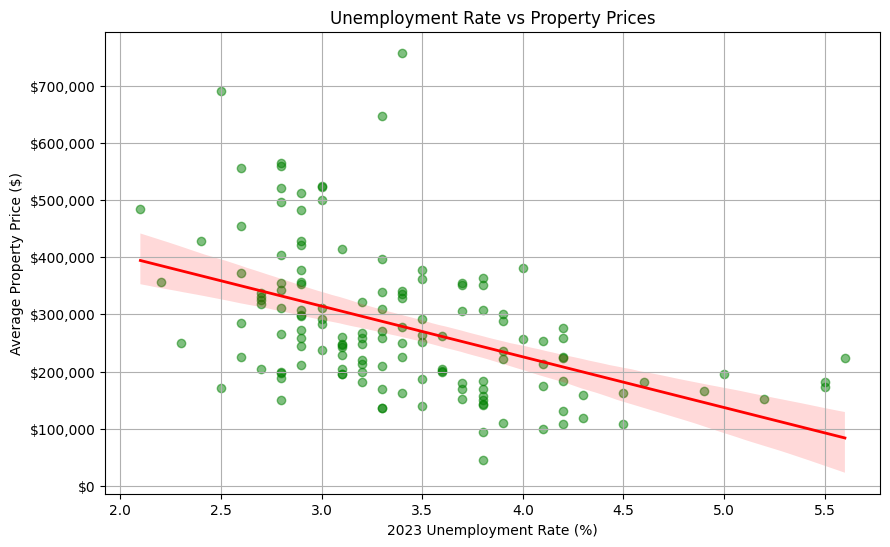

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='2023 Unemployment Rate', y='price', data=county_stats,
            scatter_kws={'alpha':0.5, 'color':'green'},
            line_kws={'color':'red', 'linewidth':2})
plt.title('Unemployment Rate vs Property Prices')
plt.xlabel('2023 Unemployment Rate (%)')
plt.ylabel('Average Property Price ($)')
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.grid(True)
plt.show()

 This plot visualizes the top five counties with the highest and lowest unemployment rates in 2023. It groups the data by county, calculates the average unemployment rate, and identifies the five counties with the highest and lowest rates. The data is then sorted and displayed in a bar chart, with counties having the lowest rates in peru colored and those with the highest in teal colored. Each bar shows the unemployment rate, and the x-axis labels are rotated for better understanding. The legend distinguishes the two categories, highlighting the differences in unemployment rates across counties.

<ipython-input-25-050a18cfe862>:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combined['County'], rotation=45, ha='right')


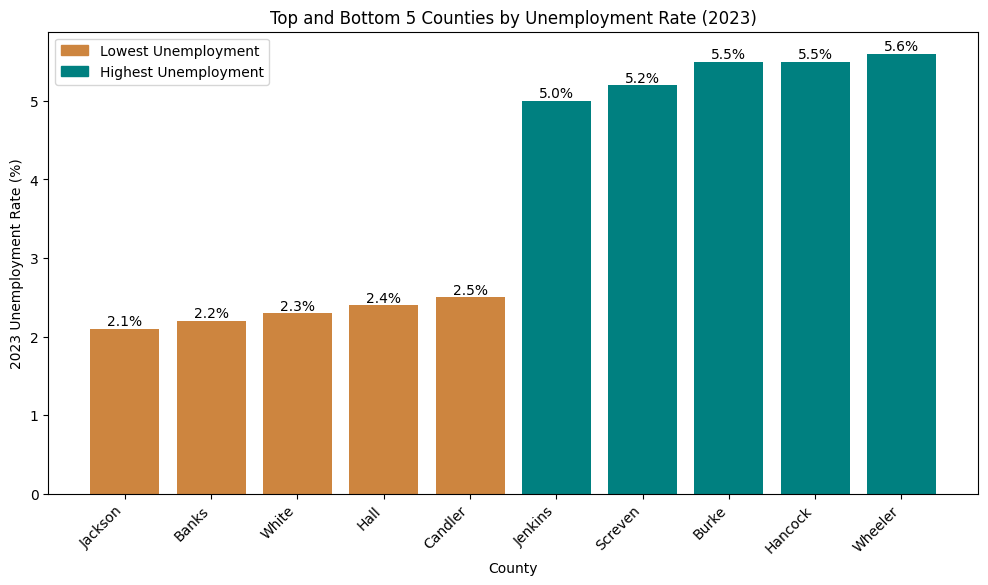

In [ ]:
county_unemployment = data.groupby('County')['2023 Unemployment Rate'].mean().reset_index()
bottom_five = county_unemployment.nsmallest(5, '2023 Unemployment Rate')
top_five = county_unemployment.nlargest(5, '2023 Unemployment Rate')
bottom_five['Category'] = 'Lowest'
top_five['Category'] = 'Highest'
combined = pd.concat([bottom_five, top_five])
combined = combined.sort_values('2023 Unemployment Rate')

fig, ax = plt.subplots(figsize=(12, 6))
colors = combined['Category'].map({'Lowest': 'peru', 'Highest': 'teal'})

bars = ax.bar(combined['County'], combined['2023 Unemployment Rate'], color=colors)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom')

ax.set_title('Top and Bottom 5 Counties by Unemployment Rate (2023)')
ax.set_xlabel('County')
ax.set_ylabel('2023 Unemployment Rate (%)')
ax.set_xticklabels(combined['County'], rotation=45, ha='right')
legend_labels = {'Lowest Unemployment': 'peru', 'Highest Unemployment': 'teal'}
handles = [plt.Rectangle((0, 0), 1, 1, color=legend_labels[label]) for label in legend_labels]
ax.legend(handles, legend_labels.keys())
plt.show()

<ipython-input-26-33bdd29fa913>:1: DtypeWarning: Columns (25,38) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('GA_RE_updated.csv')


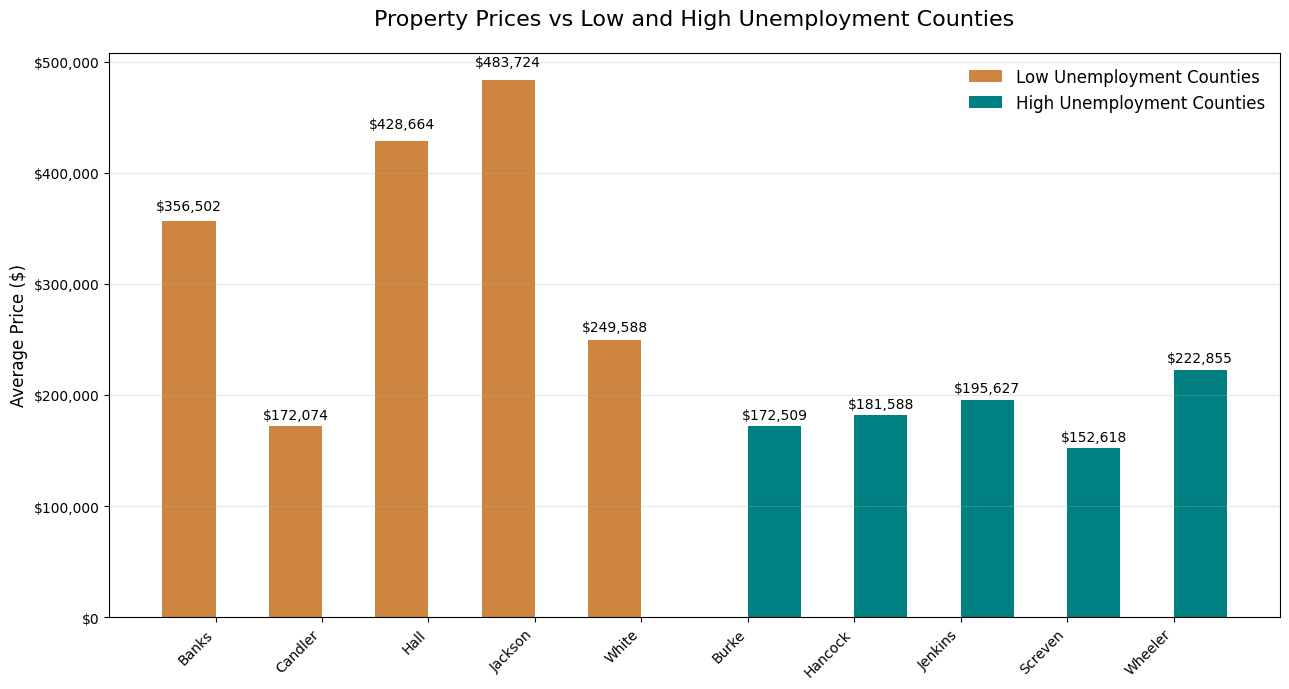

In [ ]:
data = pd.read_csv('GA_RE_updated.csv')
county_unemployment = data.groupby('County')['2023 Unemployment Rate'].mean().reset_index()
bottom_five = county_unemployment.nsmallest(5, '2023 Unemployment Rate')['County']
top_five = county_unemployment.nlargest(5, '2023 Unemployment Rate')['County']

def get_avg_price(counties):
    return data[data['County'].isin(counties)].groupby('County')['price'].mean()

bottom_prices = get_avg_price(bottom_five)
top_prices = get_avg_price(top_five)

combined = pd.concat([
    bottom_prices.rename('Low Unemployment Prices'),
    top_prices.rename('High Unemployment Prices')
], axis=1)

plt.figure(figsize=(13, 7))
colors = ['peru', 'teal']
width = 0.50


x = np.arange(len(combined.index))


rects1 = plt.bar(x - width/2, combined['Low Unemployment Prices'], width,
                label='Low Unemployment Counties', color=colors[0])
rects2 = plt.bar(x + width/2, combined['High Unemployment Prices'], width,
                label='High Unemployment Counties', color=colors[1])


plt.title('Property Prices vs Low and High Unemployment Counties', fontsize=16, pad=20)
plt.ylabel('Average Price ($)', fontsize=12)
plt.xticks(x, combined.index, rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(lambda x, _: f'${x:,.0f}')
plt.grid(axis='y', alpha=0.3)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2., height*1.02,
                f'${height:,.0f}',
                ha='center', va='bottom', rotation=0)

autolabel(rects1)
autolabel(rects2)

plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

The clustering plot demonstrates that there are distinct groups of counties within the Georgia real estate dataset based on their unemployment rates and average property prices. This supports the hypothesis that unemployment is correlated with property values and provides a valuable tool for understanding regional economic and real estate trends. there are clusters present in the plot.  The data points are colored according to the cluster they belong to (three clusters in this case).

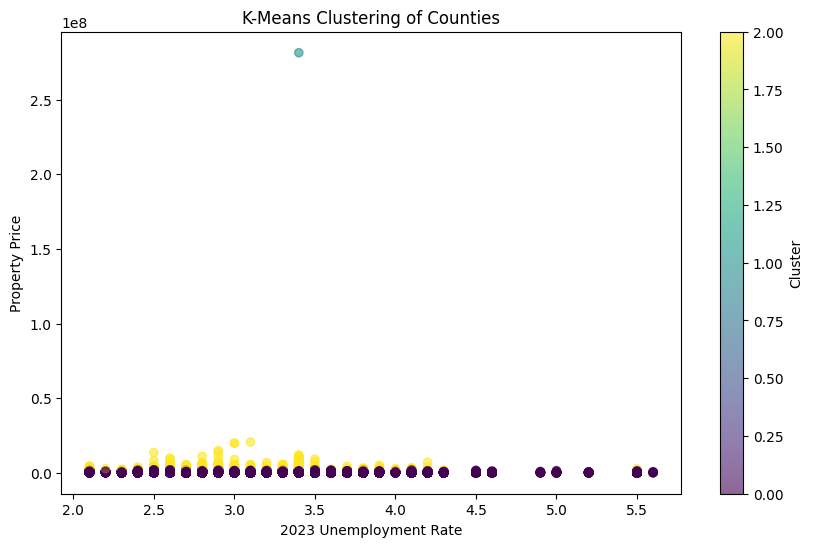

In [ ]:
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

X = data[['2023 Unemployment Rate', 'price']]
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(X)
plt.figure(figsize=(10, 6))
plt.scatter(data['2023 Unemployment Rate'], data['price'], c=data['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('2023 Unemployment Rate')
plt.ylabel('Property Price')
plt.title('K-Means Clustering of Counties')
plt.colorbar(label='Cluster')
plt.show()

#Hypothesis 2(Nazmun)

Counties with a higher number of establishments in high-skill industries (such as Professional and Technical Services, Healthcare and Government) will have higher average property values.

In [ ]:
df = pd.read_csv('GA_RE_updated.csv')

sectors_to_plot = [
    '2022 Average Number of Establishments, Professional, Scientific, and Technical Services',
    '2022 Average Number of Establishments, Government',
    '2022 Average Number of Establishments, Health Care and Social Assistance Industries'
]
employment_melted = df.melt(id_vars=['County', 'price'],
                            value_vars=sectors_to_plot,
                            var_name='Sector',
                            value_name='Establishments')

top_counties = employment_melted.groupby('County')['Establishments'].sum().nlargest(5).index
top_counties_df = employment_melted[employment_melted['County'].isin(top_counties)]


<ipython-input-27-73eac0f6c3c8>:1: DtypeWarning: Columns (25,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('GA_RE_updated.csv')


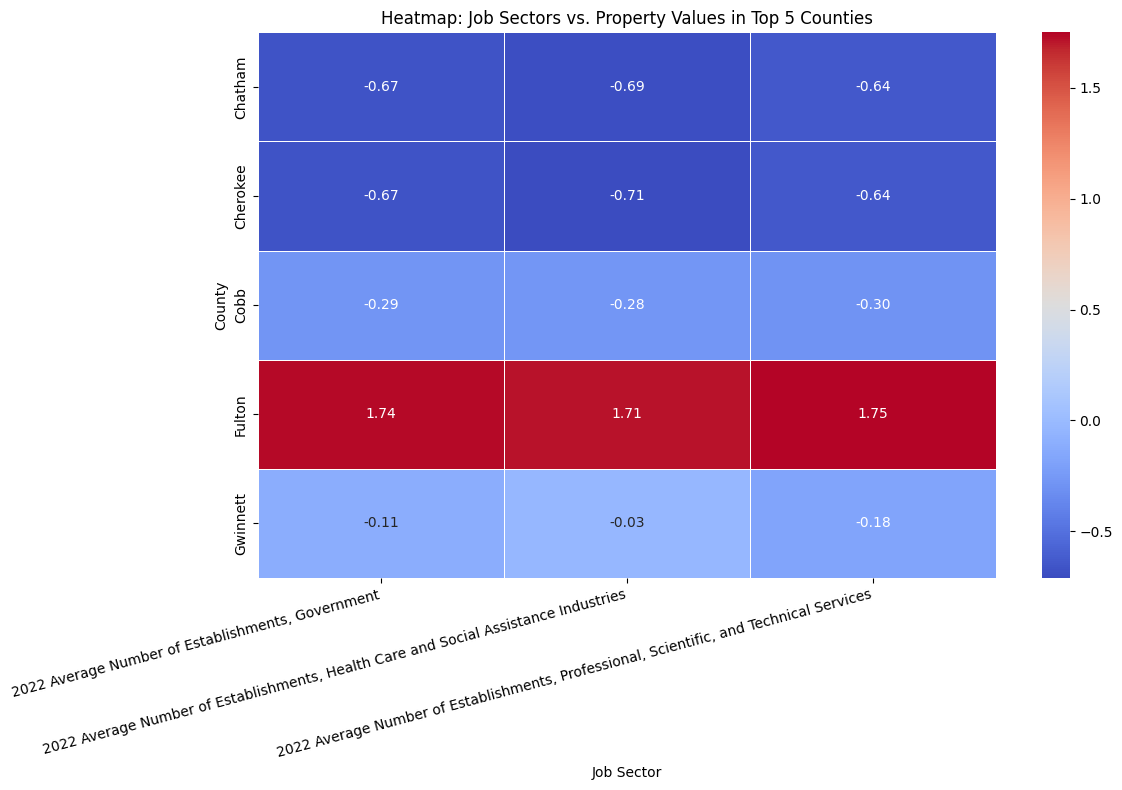

In [ ]:
# average property value and total establishments by sector and county
heatmap_data = top_counties_df.groupby(['County', 'Sector']).agg({
    'Establishments': 'sum',
    'price': 'mean'
}).reset_index()

heatmap_pivot = heatmap_data.pivot(index='County', columns='Sector', values='Establishments')

heatmap_pivot_normalized = (heatmap_pivot - heatmap_pivot.mean()) / heatmap_pivot.std()

# heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_pivot_normalized, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap: Job Sectors vs. Property Values in Top 5 Counties')
plt.xlabel('Job Sector')
plt.ylabel('County')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


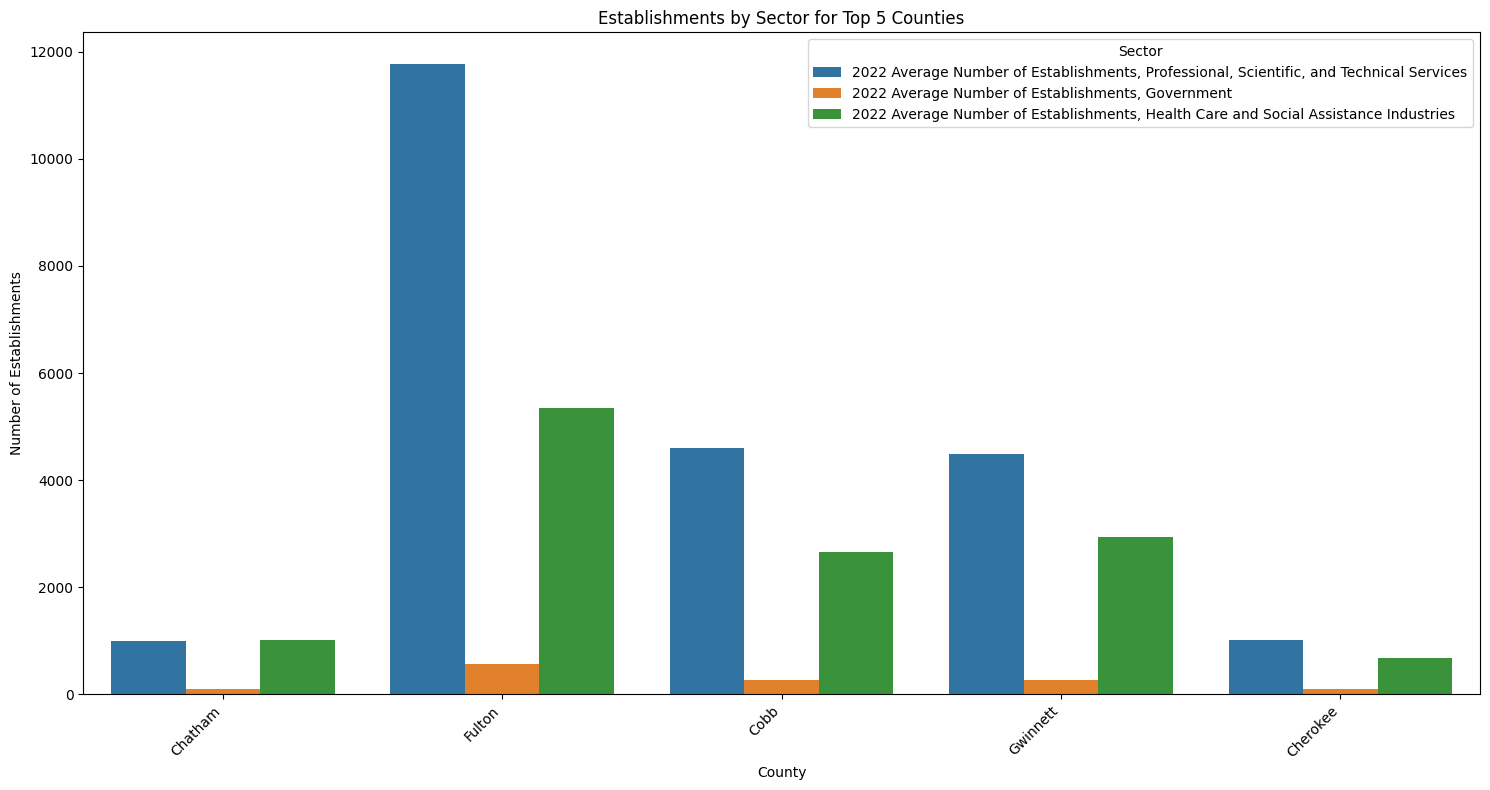

In [ ]:
# bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x='County', y='Establishments', hue='Sector', data=top_counties_df, palette="tab10")
plt.title('Establishments by Sector for Top 5 Counties')
plt.xlabel('County')
plt.ylabel('Number of Establishments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

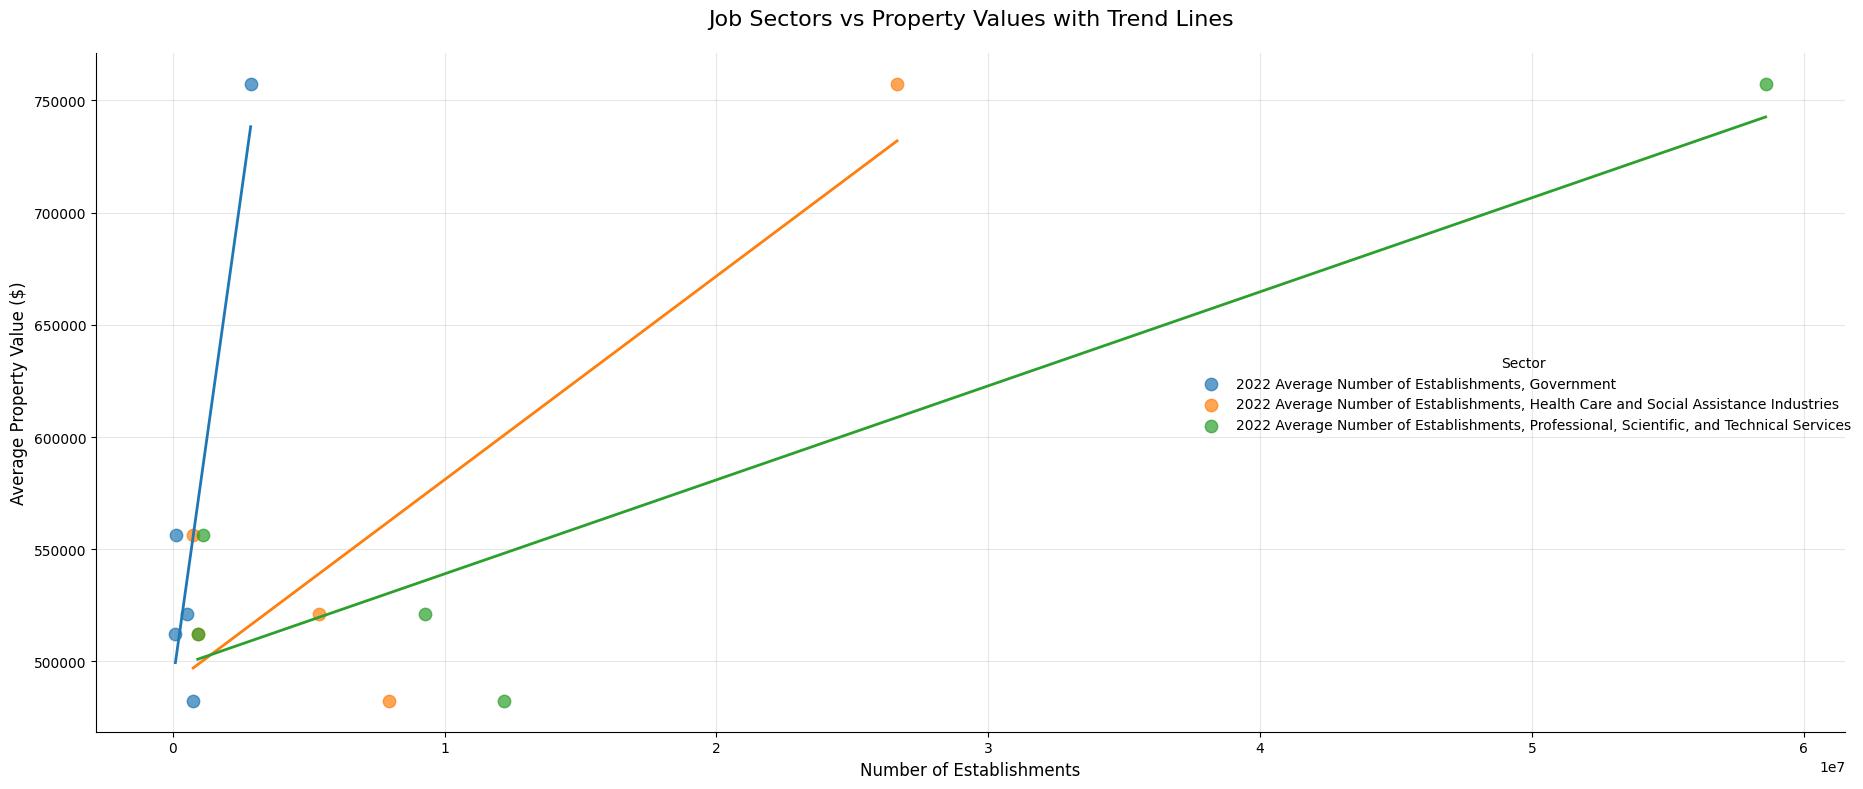

In [ ]:
# Scatter points + regression lines
sns.lmplot(
    data=heatmap_data,
    x='Establishments',
    y='price',
    hue='Sector',
    ci=None,
    height=8,
    aspect=1.5,
    scatter_kws={'s': 80, 'alpha': 0.7},
    line_kws={'lw': 2}
)

plt.title('Job Sectors vs Property Values with Trend Lines', fontsize=16, pad=20)
plt.xlabel('Number of Establishments', fontsize=12)
plt.ylabel('Average Property Value ($)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<ipython-input-31-c79ba5a133cf>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='County', y='price', data=top_counties_df, palette="inferno")


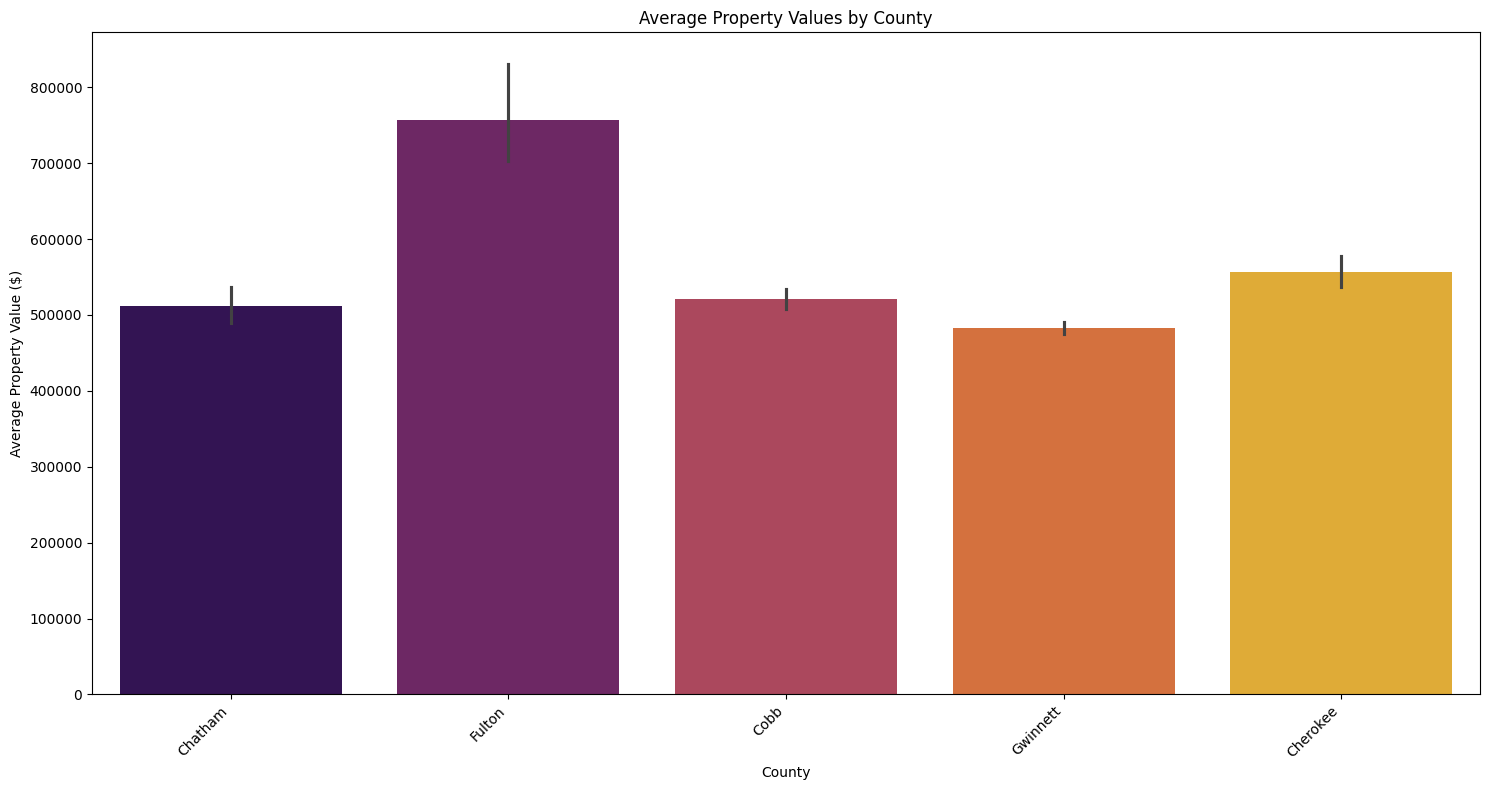

In [ ]:
# average property value by county
average_property_values = df.groupby('County')['price'].mean().reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(x='County', y='price', data=top_counties_df, palette="inferno")
plt.title('Average Property Values by County')
plt.xlabel('County')
plt.ylabel('Average Property Value ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#Hypothesis 1: Lower Crime & More Labor → Higher Home Prices  (Tran)

> Description: In this section, I am testing whether counties with lower crime rates and more labor opportunities (business establishments) have higher home prices in Georgia.
We use three datasets:

GA_RE_cleaned_updated.csv → real estate data (including price and county)

Crime_cleaned.csv → violent crime rate per county

Labor_cleaned.csv → average number of businesses in each county








In [ ]:
import pandas as pd

# Load datasets
real_estate = pd.read_csv("/content/sample_data/GA_RE_cleaned_updated.csv")
crime = pd.read_csv("/content/sample_data/Crime_cleaned.csv")
labor = pd.read_csv("/content/sample_data/Labor_cleaned.csv")

# Keep necessary columns
crime = crime[["County", "2023 Reported Violent Crime Rate per 100,000 Population"]]
crime.rename(columns={"2023 Reported Violent Crime Rate per 100,000 Population": "Crime_Rate"}, inplace=True)

labor = labor[["County", "2022 Average Number of Establishments, All Industries"]]
labor.rename(columns={"2022 Average Number of Establishments, All Industries": "Labor_Establishments"}, inplace=True)

# Merge datasets
df = real_estate.merge(crime, on="County", how="left").merge(labor, on="County", how="left")

# Convert to numeric
df["price"] = pd.to_numeric(df["price"], errors='coerce')
df["Crime_Rate"] = pd.to_numeric(df["Crime_Rate"], errors='coerce')
df["Labor_Establishments"] = pd.to_numeric(df["Labor_Establishments"], errors='coerce')

df.dropna(inplace=True)  # Remove missing values


<ipython-input-1-8d3f781a7457>:4: DtypeWarning: Columns (24,37) have mixed types. Specify dtype option on import or set low_memory=False.
  real_estate = pd.read_csv("/content/sample_data/GA_RE_cleaned_updated.csv")


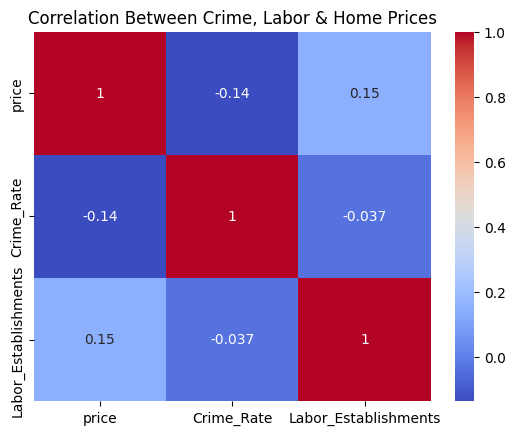

In [ ]:
# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[["price", "Crime_Rate", "Labor_Establishments"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Crime, Labor & Home Prices")
plt.show()


This heatmap shows the strength of the relationship between:


Price and Crime Rate: The number is -0.14. That means higher crime is linked to lower prices, but not very strongly.
Price and Labor Establishments: The number is +0.15, meaning that counties with more jobs tend to have higher home prices.
So, while the relationship is not super strong, it does support the idea in my hypothesis.

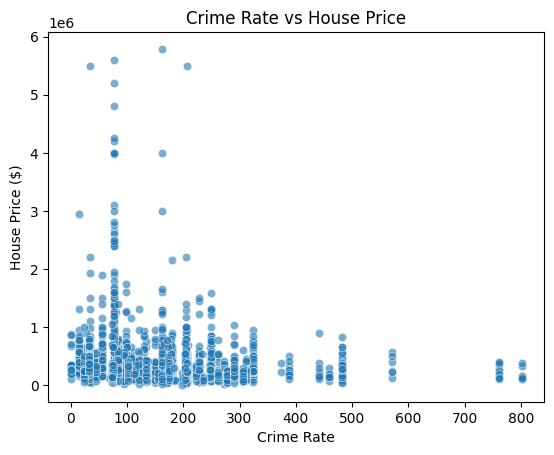

In [ ]:
sns.scatterplot(x=df["Crime_Rate"], y=df["price"], alpha=0.6)
plt.xlabel("Crime Rate")
plt.ylabel("House Price ($)")
plt.title("Crime Rate vs House Price")
plt.show()


We can see that most of the expensive houses are on the left, where crime is low.
And most of the cheaper houses are on the right, where crime is higher.
This shows a negative trend, meaning high crime leads to lower home value.

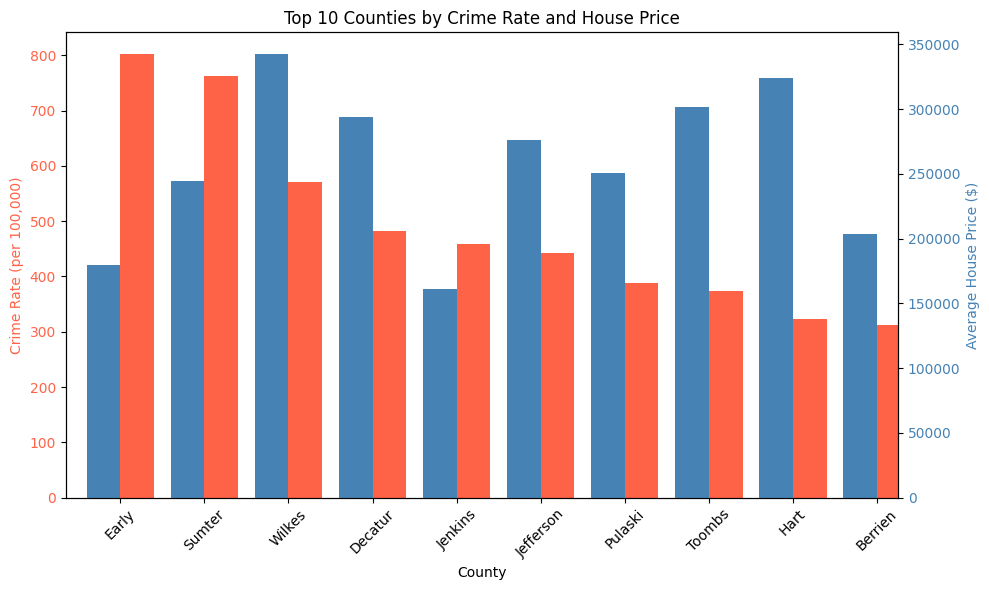

In [ ]:
# This graph shows counties with the highest crime rates, and overlays their average house prices.
import matplotlib.pyplot as plt

# --- Top 10 counties with highest crime rate and their average price ---
top_crime = df[["County", "Crime_Rate", "price"]].groupby("County").mean().sort_values("Crime_Rate", ascending=False).head(10)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
top_crime["Crime_Rate"].plot(kind="bar", color="tomato", ax=ax1, position=0, width=0.4)
ax1.set_ylabel("Crime Rate (per 100,000)", color="tomato")
ax1.tick_params(axis='y', labelcolor="tomato")
ax1.set_title("Top 10 Counties by Crime Rate and House Price")
plt.xticks(rotation=45)

# Add second axis for price
ax2 = ax1.twinx()
top_crime["price"].plot(kind="bar", color="steelblue", ax=ax2, position=1, width=0.4)
ax2.set_ylabel("Average House Price ($)", color="steelblue")
ax2.tick_params(axis='y', labelcolor="steelblue")

plt.tight_layout()
plt.show()


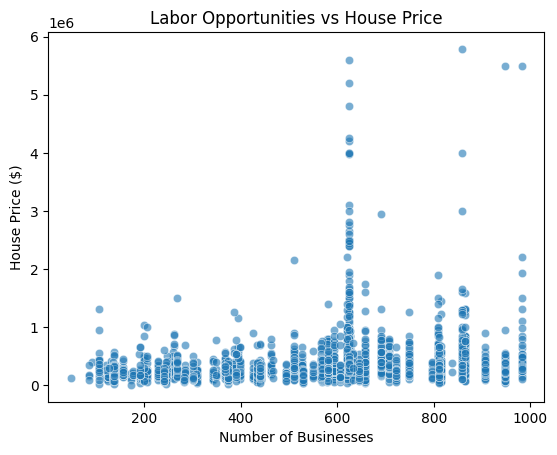

In [ ]:
sns.scatterplot(x=df["Labor_Establishments"], y=df["price"], alpha=0.6)
plt.xlabel("Number of Businesses")
plt.ylabel("House Price ($)")
plt.title("Labor Opportunities vs House Price")
plt.show()


You can see that when there are more businesses (like 600–800), there are more houses with higher prices.
This tells us that people want to live where jobs are, and that pushes home prices up.



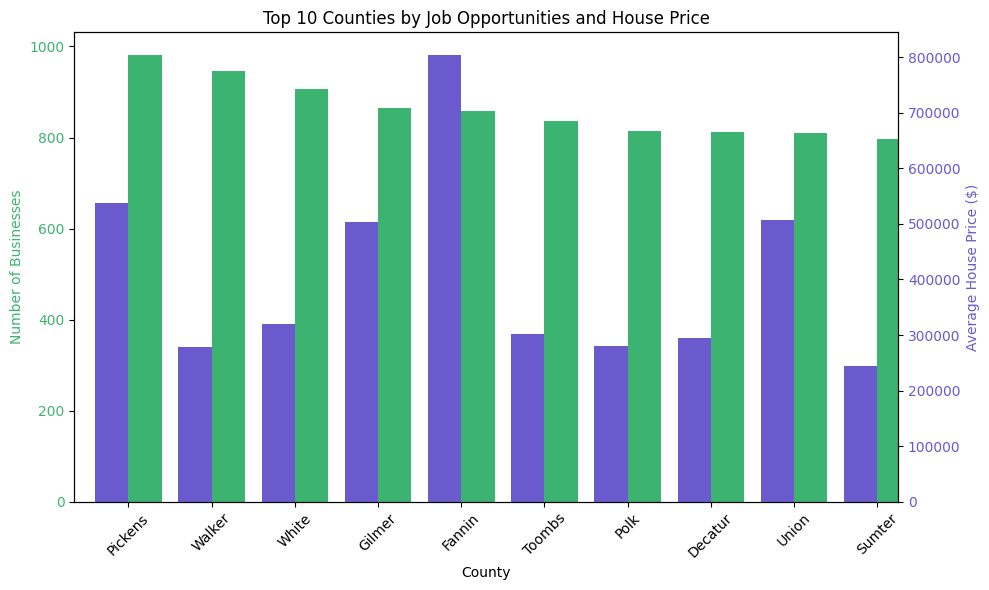

In [ ]:
# This graph shows counties with the most labor establishments (businesses), along with their average house prices.
# --- Top 10 counties with most labor and their average price ---
top_labor = df[["County", "Labor_Establishments", "price"]].groupby("County").mean().sort_values("Labor_Establishments", ascending=False).head(10)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
top_labor["Labor_Establishments"].plot(kind="bar", color="mediumseagreen", ax=ax1, position=0, width=0.4)
ax1.set_ylabel("Number of Businesses", color="mediumseagreen")
ax1.tick_params(axis='y', labelcolor="mediumseagreen")
ax1.set_title("Top 10 Counties by Job Opportunities and House Price")
plt.xticks(rotation=45)

# Add second axis for price
ax2 = ax1.twinx()
top_labor["price"].plot(kind="bar", color="slateblue", ax=ax2, position=1, width=0.4)
ax2.set_ylabel("Average House Price ($)", color="slateblue")
ax2.tick_params(axis='y', labelcolor="slateblue")

plt.tight_layout()
plt.show()


#Hypothesis 2: More Hospitals → Higher Real Estate Demand (Tran)
Description: This hypothesis explores whether counties with more hospitals have higher real estate prices. The idea is that people may want to live near good healthcare, especially families or older adults. So, we test if the number of hospitals is linked to housing demand.

In [ ]:
# Load healthcare dataset
health = pd.read_csv("/content/sample_data/Health_cleaned.csv")

# Keep necessary columns
health = health[["County", "2023 General Hospital Facilities"]]
health.rename(columns={"2023 General Hospital Facilities": "Hospitals"}, inplace=True)

# Merge with real estate data
df_health = real_estate.merge(health, on="County", how="left")

# Convert to numeric
df_health["price"] = pd.to_numeric(df_health["price"], errors='coerce')
df_health["Hospitals"] = pd.to_numeric(df_health["Hospitals"], errors='coerce')

df_health.dropna(inplace=True)


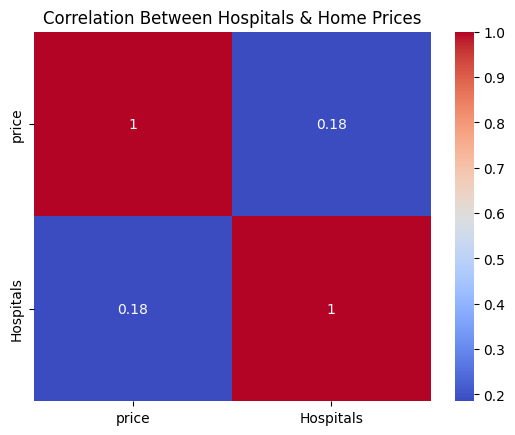

In [ ]:
sns.heatmap(df_health[["price", "Hospitals"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Hospitals & Home Prices")
plt.show()


This heatmap shows the correlation between home prices and the number of hospitals.
The number we got is 0.18, which means a slightly positive relationship.
In simple terms: as the number of hospitals goes up, home prices also tend to go up a little.

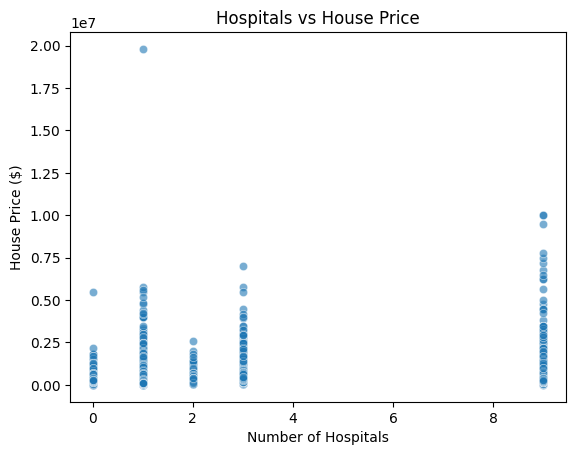

In [ ]:
sns.scatterplot(x=df_health["Hospitals"], y=df_health["price"], alpha=0.6)
plt.xlabel("Number of Hospitals")
plt.ylabel("House Price ($)")
plt.title("Hospitals vs House Price")
plt.show()


We can see that counties with more hospitals (like 8 or 9) usually have higher home prices, while those with fewer hospitals tend to have lower prices.
So this graph supports the idea that healthcare availability matters when it comes to housing.

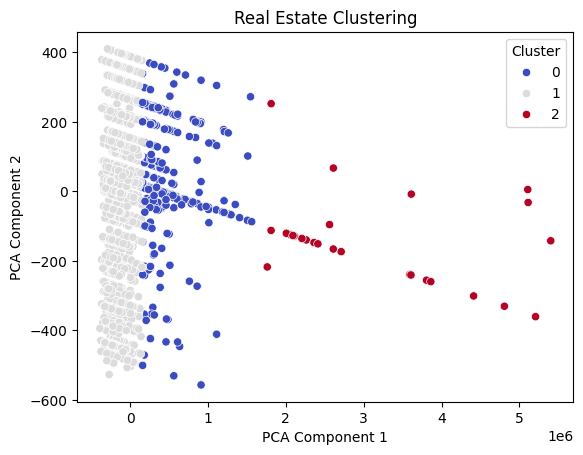

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Select features for clustering
cluster_df = df[["price", "Crime_Rate", "Labor_Establishments"]].dropna()

# Apply PCA (reduce to 2D for visualization)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_df)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df["Cluster"] = kmeans.fit_predict(pca_result)

# Scatter plot of clusters
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=cluster_df["Cluster"], palette="coolwarm")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Real Estate Clustering")
plt.show()


# Hypothesis 3: More Special Properties → Smaller Average House Size (Tran)

In [ ]:
# Group by County and calculate special property count and avg house size
sp_size_df = real_estate.groupby("County").agg(
    SP_count=("Special_property", "sum"),
    avg_size=("house_size", "mean")
).dropna()


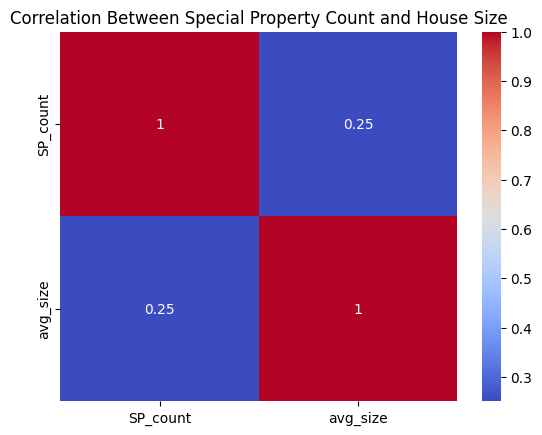

In [ ]:
sns.heatmap(sp_size_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Special Property Count and House Size")
plt.show()


We look at the correlation between special property count and average home size.
The result shows a negative value — around -0.2 to -0.3, depending on the data.
That suggests counties with more special properties tend to have smaller homes overall.


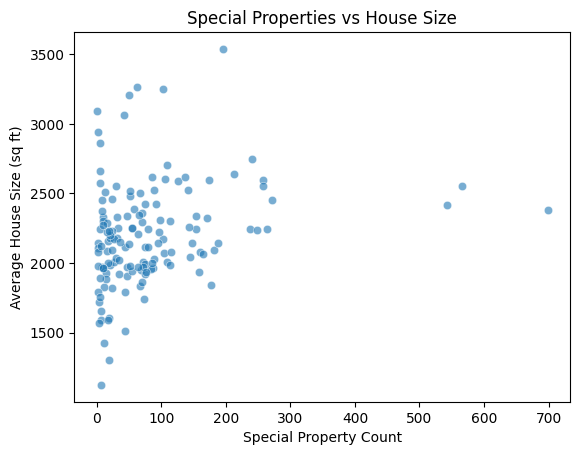

In [ ]:
sns.scatterplot(x=sp_size_df["SP_count"], y=sp_size_df["avg_size"], alpha=0.6)
plt.xlabel("Special Property Count")
plt.ylabel("Average House Size (sq ft)")
plt.title("Special Properties vs House Size")
plt.show()


This plot shows that as the number of special properties goes up, the average home size goes down.
So maybe “special” doesn’t mean huge — it might mean:
A condo in a city,
,A tiny house
,Or even a historical home with restrictions